In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scripts import training, model
from torch.utils.data import TensorDataset, DataLoader
import random
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
g = torch.Generator()
g.manual_seed(42)


In [58]:
X_train = torch.load("LSTM Files/Tensors/X_train.pt")
M_train = torch.load("LSTM Files/Tensors/M_train.pt")
Y_train = torch.load("LSTM Files/Tensors/Y_train.pt")

X_valid = torch.load("LSTM Files/Tensors/X_valid.pt") 
M_valid = torch.load("LSTM Files/Tensors/M_valid.pt") 
Y_valid = torch.load("LSTM Files/Tensors/Y_valid.pt")

X_test = torch.load("LSTM Files/Tensors/X_test.pt")
M_test = torch.load("LSTM Files/Tensors/M_test.pt") 
Y_test = torch.load("LSTM Files/Tensors/Y_test.pt")

yscale = joblib.load("LSTM Files/yscale.pkl")
xscale = joblib.load("LSTM Files/xscale.pkl")

/var/folders/gt/m7_lxk5j1mn90fqjrx8y57300000gn/T/ipykernel_89335/1894238820.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train = torch.load("LSTM Files/Tensors/X_tr

Now lets load the data for the LSTM

In [59]:
train_loaded = DataLoader(
    TensorDataset(X_train, M_train, Y_train),
    batch_size=64,
    shuffle=True,
    generator=g,
    num_workers=0
)

val_loaded = DataLoader(
    TensorDataset(X_valid, M_valid, Y_valid),
    batch_size=64,
    shuffle=False,
    generator=g,
    num_workers=0
)

test_loaded = DataLoader(
    TensorDataset(X_test, M_test, Y_test),
    batch_size=64,
    shuffle=False,
    generator=g,
    num_workers=0
)

model time - Train 

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #setting my device

#initalize model
model_flow = model.LSTM(input_size=X_train.shape[-1]).to(device)

#loss/optimizer
loss_func = nn.MSELoss()
optimizer = optim.Adam(model_flow.parameters(), lr=.001) 

Actually train it 

In [61]:
epochs = 50
best_val_loss = np.inf
patience = 10
patience_counter = 0
best_state = None
history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):

    #training
    model_flow.train()
    losses = []

    for x_train, mask, y_train in train_loaded:
        x_train, mask, y_train = x_train.to(device), mask.to(device), y_train.to(device)

        optimizer.zero_grad()
        prediction = model_flow(x_train, mask)

        loss = loss_func(prediction, y_train)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    #validation
    model_flow.eval()
    validate_loss = []

    with torch.no_grad():
        for x_valid, mask, y_valid in val_loaded:
            x_valid, mask, y_valid = x_valid.to(device), mask.to(device), y_valid.to(device)

            prediction = model_flow(x_valid, mask)
            loss = loss_func(prediction, y_valid)

            validate_loss.append(loss.item())

    #Print mean every epoch so I can watch it over time live, store in history to graph 
    train_mean = np.mean(losses)
    history['train_loss'].append(train_mean)
    val_mean = np.mean(validate_loss)
    history['val_loss'].append(val_mean)

    print(f"Epoch {epoch+1} | "
    f"Train Loss: {train_mean:.5f} | "
    f"Val Loss: {val_mean:.5f}")

    #early stop
    if val_mean < best_val_loss:
        best_val_loss = val_mean
        best_state = {k: v.cpu().clone() for k, v in model_flow.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model_flow.load_state_dict(best_state)
    torch.save(model_flow.state_dict(), "LSTM.pt")

Epoch 1 | Train Loss: 0.00456 | Val Loss: 0.00799
Epoch 2 | Train Loss: 0.00259 | Val Loss: 0.00428
Epoch 3 | Train Loss: 0.00192 | Val Loss: 0.00634
Epoch 4 | Train Loss: 0.00172 | Val Loss: 0.00522
Epoch 5 | Train Loss: 0.00205 | Val Loss: 0.00495
Epoch 6 | Train Loss: 0.00154 | Val Loss: 0.00666
Epoch 7 | Train Loss: 0.00145 | Val Loss: 0.00532
Epoch 8 | Train Loss: 0.00140 | Val Loss: 0.00641
Epoch 9 | Train Loss: 0.00138 | Val Loss: 0.00626
Epoch 10 | Train Loss: 0.00129 | Val Loss: 0.00392
Epoch 11 | Train Loss: 0.00134 | Val Loss: 0.00534
Epoch 12 | Train Loss: 0.00126 | Val Loss: 0.00671
Epoch 13 | Train Loss: 0.00121 | Val Loss: 0.00452
Epoch 14 | Train Loss: 0.00116 | Val Loss: 0.00602
Epoch 15 | Train Loss: 0.00120 | Val Loss: 0.00424
Epoch 16 | Train Loss: 0.00111 | Val Loss: 0.00623
Epoch 17 | Train Loss: 0.00105 | Val Loss: 0.00518
Epoch 18 | Train Loss: 0.00113 | Val Loss: 0.00531
Epoch 19 | Train Loss: 0.00106 | Val Loss: 0.00624
Epoch 20 | Train Loss: 0.00111 | Val Los

view the model performance 

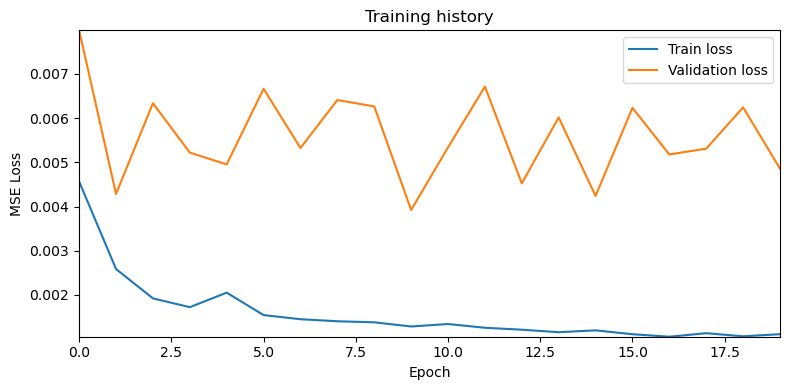

In [62]:
model.plot_training(history)

test it 

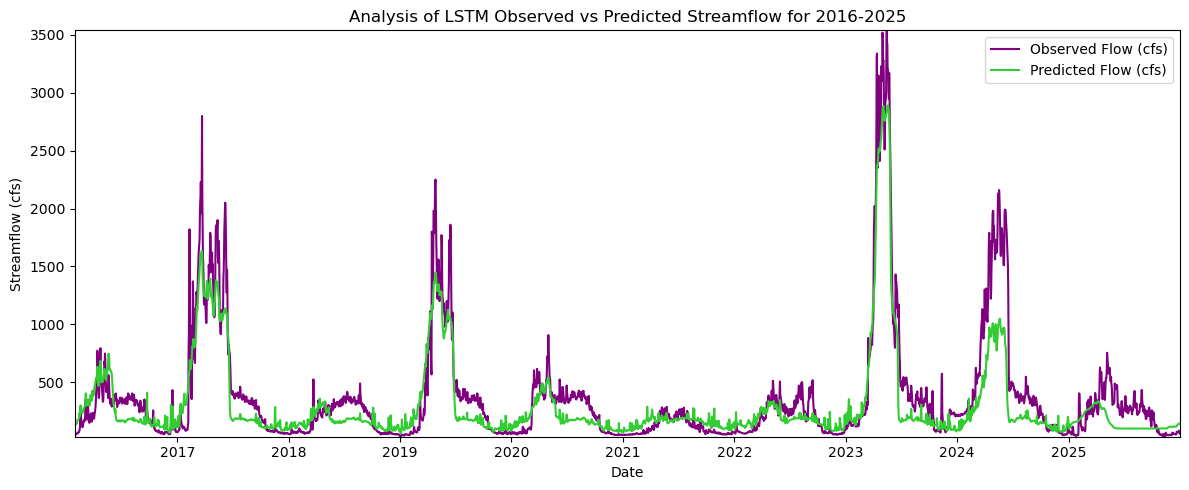

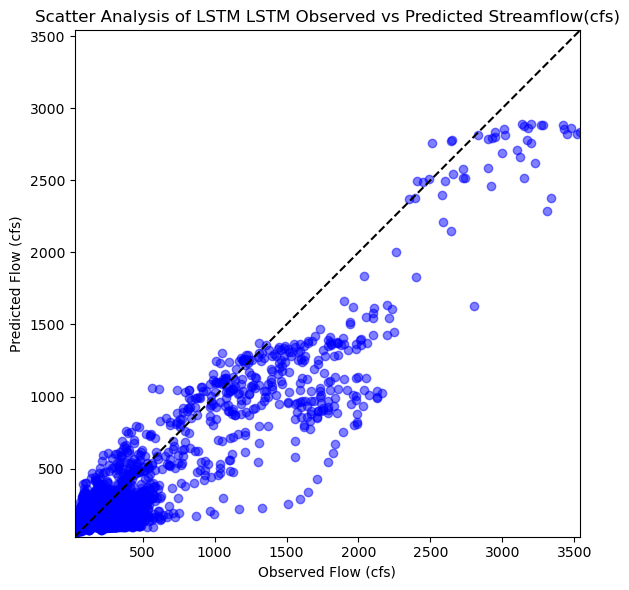

RMSE: 211.761
MAE:  138.778
R2:   0.819
Relative Error: 0.382


In [63]:
#pull dates from saved df, we will just use Q since we need it later in the evaluate parameters
true_Q = pd.read_csv("Data Files/Streamflow/10136500_discharge.csv")
true_Q["Date"] = pd.to_datetime(true_Q['Date'])
dates = true_Q["Date"].iloc[30:]
model.evaluate(model_flow, test_loaded, device, yscale,dates,true_Q)